## Imports & Constants

In [1]:
from IPython.display import display

# also run pip install jinja2
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from gerrychain import (Partition, Graph, updaters, MarkovChain, constraints, accept)
from gerrychain.proposals import recom
from gerrychain.constraints import contiguous
from gerrychain.updaters import cut_edges
from gerrychain.tree import recursive_tree_part
from functools import partial

import random

MARKOV_STEPS = 500
DESIRED_TCP = 0.56

## Process Initial Data

In [2]:
# read voter district map and mggg community cluster map
vtds = gpd.read_file("data/mo_2020_vtd/mo_2020.shp")
cois = gpd.read_file("data/mo_2021_coi/MO_20210924_phase_C_summary.shp")

# find subclusters to drop parents
subclusters = cois[cois['cluster'].str.contains('-')]
parents_to_drop = subclusters['cluster'].apply(lambda x: x.split('-')[0]).unique()
cois = cois[~cois['cluster'].isin(parents_to_drop)]

# align coords on both maps
if cois.crs != vtds.crs:
    vtds = vtds.to_crs(cois.crs)

## datas missing a total pop column, so add up presidential votes to get
pres_cols = ['G20PRERTRU', 'G20PREDBID', 'G20PRELJOR', 'G20PREGHAW', 'G20PRECBLA']
vtds['TOTPOP'] = vtds[pres_cols].sum(axis=1)

## now need coi fractions per vtd
# what fraction of community resides here? coi area / total area
vtds['vtd_area'] = vtds.geometry.area
overlaps = gpd.overlay(vtds, cois, how='intersection')
overlaps['coi_fraction'] = overlaps.geometry.area / overlaps['vtd_area']

# drop tiny overlaps
clean_overlaps = overlaps[overlaps['coi_fraction'] > 0.01].copy()

# figure out num people from overlaps pct
clean_overlaps['coi_pop'] = clean_overlaps['TOTPOP'] * clean_overlaps['coi_fraction']

# build coi pop dict per vtd
coi_dict = {}
for index, row in clean_overlaps.iterrows():
    vtd_name = row['NAME']
    cluster_id = row['cluster']
    population_chunk = row['coi_pop']
    
    if vtd_name not in coi_dict:
        coi_dict[vtd_name] = {}
        
    coi_dict[vtd_name][cluster_id] = population_chunk

vtds['COI_POPS'] = [coi_dict.get(name, {}) for name in vtds['NAME']]


KeyboardInterrupt: 

### Add District Data from Congressional Maps - 2022, 2025

In [ ]:
## add enacted maps - gives district 
congressional_2025 = gpd.read_file("data/mo_2025_congressional/HB1_Cong_Dist_2025.shp")
congressional_2022 = gpd.read_file('data/mo_2022_congressional/tl_2022_29_cd118.shp')

congressional_2025 = congressional_2025.to_crs(vtds.crs)
congressional_2022 = congressional_2022.to_crs(vtds.crs)

# get center vtd points to map to congressional districts
vtd_points = vtds.copy()
vtd_points.geometry = vtd_points.representative_point()

joined_vtds_2025 = gpd.sjoin(vtd_points, congressional_2025, how="left", predicate="intersects")
joined_vtds_2022 = gpd.sjoin(vtd_points, congressional_2022, how="left", predicate="intersects")

vtds['district_2025'] = joined_vtds_2025['District']
vtds['district_2022'] = joined_vtds_2022['CD118FP'].astype(int)


#### Debug

In [ ]:

#print(vtds.columns)
#display(vtds[['NAME', 'TOTPOP', 'COI_POPS', 'district_2022','district_2025']].head(10))

#vtds.to_csv('vtds.csv', columns=['NAME','TOTPOP','COI_POPS'])

## Markov Chaining

### Helper Functions

In [ ]:

def extract_data(partition):
    data_rows = []

    for node_id in partition.graph.nodes:
        assigned_dist = partition.assignment[node_id]
        # grab the dict with community pop info
        node_cois = partition.graph.nodes[node_id].get("COI_POPS", {})
        for coi_id, coi_pop in node_cois.items():
            data_rows.append(
                {
                    #TODO: no categories for this data so just 1 'coi' bucket, maybe NLP will give us categories later
                    "category": "coi",
                    "community_id": coi_id,
                    "district": assigned_dist,
                    "pop": coi_pop,
                }
            )

    return pd.DataFrame(data_rows)

def plot_partition(partition, vtds, cois, title):
    # map districts to df
    vtds['district'] = vtds.index.map(partition.assignment)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    vtds.plot(ax=ax, column="district", cmap='Pastel1',edgecolor="black", linewidth=0.15)
    #cois.plot(ax=ax, column="cluster", facecolor='none', edgecolor="red", linewidth=0.15)

    if title:
        ax.set_title(title, fontsize=16)
    ax.axis("off")
    plt.show()


### Updaters (Scoring Functions)

In [ ]:
def score_communities(unscored_df):
    """
    calculates the sum of squared shares for each community

    inputs:
        unscored_df: df with cols: category, community_id, district, pop
    outputs:
        communities_scores: df with cols: category, community_id, total_pop, sss_score
    """
    # get total pop per community (water1, water2..)
    total_pops = unscored_df.groupby(['category', 'community_id'])['pop'].sum().reset_index()
    total_pops.rename(columns={'pop': 'total_pop'}, inplace=True)

    # get pop per community and district
    district_splits = unscored_df.groupby(['category', 'community_id', 'district'])['pop'].sum().reset_index()

    # merge to get pop / total pop
    merged = pd.merge(district_splits, total_pops, on=['category', 'community_id'])

    # get squared shares
    merged['share'] = merged['pop'] / merged['total_pop']
    merged['squared_share'] = merged['share'] ** 2

    # sum squared shares across all communities in each category
    # this is the 'final' score for each community (not grouped yet)
    final_sss_df = merged.groupby(['category', 'community_id', 'total_pop'])['squared_share'].sum().reset_index()
    final_sss_df.rename(columns={'squared_share': 'sss_score'}, inplace=True)
    return final_sss_df

def score_overall(dataframe, weights):
    """
    calculates the total coi preservation as a single metric between 0 and 1

    inputs:
        dataframe: output from score_communities()
        weights: dict with keys: category, values: weight
    outputs:
        final_score: total coi preservation (tcp) between 0 and 1
    """
    # after getting sss score for each community, we want 1 final metric
    # bigger populations need more weight in category averages
    # get pop weighted avg for each community - sum(pop[i] * coi score / category pop
    dataframe['weighted_score'] = dataframe['sss_score'] * dataframe['total_pop']
    category_score_sums = dataframe.groupby('category')['weighted_score'].sum()
    category_pop_sums = dataframe.groupby('category')['total_pop'].sum()

    # gets our category averages
    pop_weighted_avg = category_score_sums / category_pop_sums
    # multiply each category score by weight and sum for final metric
    final_score = (pop_weighted_avg * pd.Series(weights)).sum()
    return final_score

def calculate_tcp(partition):
    # arbitrary
    #weights = {'water': 0.5, 'county': 0.3, 'muni': 0.2}
    # TODO: get NLP to categorize and weight
    weights = {'coi': 1}

    raw_df = extract_data(partition)
    community_scores = score_communities(raw_df)
    final_score = score_overall(community_scores, weights)
    
    return final_score

def count_dem_wins(partition):
    dem_wins = 0
    for district_id, node_ids in partition.parts.items():
        dem_pop = 0
        tot_pop = 0
        for node_id in node_ids:
            # grab node info
            node_attrs = partition.graph.nodes[node_id]
            # get vote pop and total pop
            dem_pop += node_attrs['G20PREDBID']
            tot_pop += node_attrs['TOTPOP']
            
        if dem_pop / tot_pop > 0.5:
            dem_wins += 1

    return dem_wins

def dem_share(partition):
    dem_shares = []
    for district_id, node_ids in partition.parts.items():
        dem_pop = 0
        tot_pop = 0
        for node_id in node_ids:
            # grab node info
            node_attrs = partition.graph.nodes[node_id]
            # get vote pop and total pop
            dem_pop += node_attrs['G20PREDBID']
            tot_pop += node_attrs['TOTPOP']
            
        dem_share = dem_pop / tot_pop if tot_pop > 0 else 0
        dem_shares.append(dem_share)
        
    dem_shares.sort()
    return tuple(dem_shares)



### Accept Functions

In [ ]:
def optimized_tcp(partition):
    # favors maps preserved above the average amount, should see dem favor
    tcp_score = partition['tcp_score']
    chance = random.random()

    if tcp_score > DESIRED_TCP:
        return chance > 0.2
    else:
        return chance < 0.2  

def unoptimized_tcp(partition):
    # favors badly preserved maps, should see republican favor
    tcp_score = partition['tcp_score']
    chance = random.random()

    if tcp_score > DESIRED_TCP:
        return chance < 0.2
    else:
        return chance > 0.2   


### Init Graph and Chain

In [ ]:
## init graph
vtds.geometry = vtds.geometry.buffer(0)
g = Graph.from_geodataframe(vtds)

# missouri has 8 districts
total_population = sum(node.get('TOTPOP', 1) for node in g.nodes.values())
target_pop = total_population / 8

# using a gerrychain method to start with 8 equal nice contiguous parts
starting_assignment = recursive_tree_part(
    g, 
    parts=range(8), 
    pop_target=target_pop, 
    pop_col="TOTPOP", 
    epsilon=0.05
)

## init part
initial_partition = Partition(
    g, 
    assignment=starting_assignment, 
    updaters={ 
        'tcp_score': calculate_tcp,
        'cut_edges': cut_edges,
        'dem_wins': count_dem_wins,
        'dem_share': dem_share
    }
)

## init chain
proposal = partial(recom, pop_col="TOTPOP", pop_target=target_pop, epsilon=0.05, node_repeats=2)
chain = MarkovChain(
    proposal=proposal,
    constraints=[contiguous],
    accept=optimized_tcp,
    initial_state=initial_partition,
    total_steps=MARKOV_STEPS
)

/Users/jevonlipsey/miniconda3/envs/mcure/lib/python3.12/site-packages/gerrychain/graph/adjacency.py:112: UserWarning: Found overlaps among the given polygons. Indices of overlaps: {(3097, 3358), (3691, 3692), (521, 1469), (2399, 3085), (1257, 3721), (2210, 2593), (2818, 2823), (3695, 3697), (3696, 3697), (1392, 1773), (526, 1773), (3709, 3717), (3721, 3722), (1257, 3722), (1689, 1782), (3672, 3673), (2593, 3119), (674, 1773), (3693, 3694), (1617, 1843)}
  warnings.warn(


### Run Chain

In [ ]:
# collect scores
tcp_scores = []
cut_edges_count = []
dem_wins_count = []

# dem shares init
dist_1_shares = []
dist_2_shares = []
dist_3_shares = []
dist_4_shares = []
dist_5_shares = []
dist_6_shares = []
dist_7_shares = []
dist_8_shares = []

# maps score
best_score=0
best_map=None
worst_score=1
worst_map=None
overall_best_score=0
overall_best_map=None
most_seats=0

for partition in chain:
    # track every 50k steps
    if len(tcp_scores) > 0 and len(tcp_scores) % 50000 == 0:
        print(f"completed {len(tcp_scores)} steps...")

    score = partition['tcp_score']
    cuts = len(partition['cut_edges'])
    seats = partition['dem_wins']
    shares = partition['dem_share']

    tcp_scores.append(score)
    cut_edges_count.append(cuts)
    dem_wins_count.append(seats)

    dist_1_shares.append(shares[0])
    dist_2_shares.append(shares[1])
    dist_3_shares.append(shares[2])
    dist_4_shares.append(shares[3])
    dist_5_shares.append(shares[4])
    dist_6_shares.append(shares[5])
    dist_7_shares.append(shares[6])
    dist_8_shares.append(shares[7])

    # track most preserved
    if score > best_score:
        best_score = score
        best_map = partition
        
    # track least preserved
    if score < worst_score:
        worst_score = score
        worst_map = partition

    # track max minority seats, best score
    if seats > most_seats:
        most_seats = seats
        overall_best_score = score
        overall_best_map = partition
    elif seats == most_seats:
        if score > overall_best_score:
            overall_best_score = score
            overall_best_map = partition

# save to csv
chain_results = {
    'step': range(len(tcp_scores)),
    'tcp_score': tcp_scores,
    'cut_edges': cut_edges_count,
    'dem_wins': dem_wins_count,
    'dist_1_dem_share': dist_1_shares,
    'dist_2_dem_share': dist_2_shares,
    'dist_3_dem_share': dist_3_shares,
    'dist_4_dem_share': dist_4_shares,
    'dist_5_dem_share': dist_5_shares,
    'dist_6_dem_share': dist_6_shares,
    'dist_7_dem_share': dist_7_shares,
    'dist_8_dem_share': dist_8_shares
}


results_df = pd.DataFrame(chain_results)
results_df.to_csv("missouri_optimized_500.csv", index=False)


## Plots

In [ ]:
# score enacted maps for plotting
enacted_2022 = Partition(
    g,
    assignment="district_2022",
    updaters={
        'tcp_score': calculate_tcp,
        'cut_edges': cut_edges,
        'dem_wins': count_dem_wins
    }
)

enacted_2025 = Partition(
    g,
    assignment="district_2025",
    updaters={
        'tcp_score': calculate_tcp,
        'cut_edges': cut_edges,
        'dem_wins': count_dem_wins
    }
)


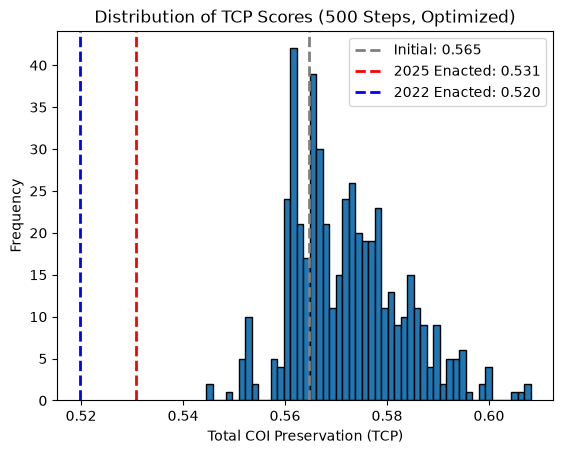

In [ ]:
# hist: tcp scores distribution
plt.hist(tcp_scores, bins=50, edgecolor="black")
initial_score = initial_partition["tcp_score"]
score_2022 = enacted_2022["tcp_score"]
score_2025 = enacted_2025["tcp_score"]

plt.axvline(
    initial_score,
    color="grey",
    linestyle="dashed",
    linewidth=2,
    label=f"Initial: {initial_score:.3f}",
)

plt.axvline(
    score_2025,
    color="red",
    linestyle="dashed",
    linewidth=2,
    label=f"2025 Enacted: {score_2025:.3f}",
)

plt.axvline(
    score_2022,
    color="blue",
    linestyle="dashed",
    linewidth=2,
    label=f"2022 Enacted: {score_2022:.3f}",
)

plt.title(f"Distribution of TCP Scores ({MARKOV_STEPS} Steps, Optimized)")
plt.xlabel("Total COI Preservation (TCP)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

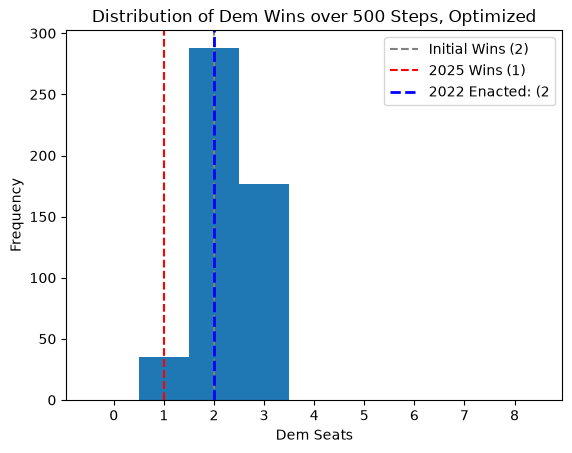

In [ ]:
# hist: dem seats distribution
n_districts = len(initial_partition.parts)
plt.hist(
    dem_wins_count, 
    bins=np.arange(-0.5, n_districts + 1.5, 1)
    )
plt.xticks(range(n_districts + 1))
plt.xlabel("Dem Seats")
plt.ylabel("Frequency")
plt.title(f"Distribution of Dem Wins over {MARKOV_STEPS} Steps, Optimized")

# initial wins line
initial_wins = count_dem_wins(initial_partition)
wins_2025 = count_dem_wins(enacted_2025)
wins_2022 = count_dem_wins(enacted_2022)

plt.axvline(
    x=initial_wins, 
    color='grey', 
    linestyle='dashed', 
    label=f'Initial Wins ({initial_wins})')

plt.axvline(
    x=wins_2025, 
    color='red', 
    linestyle='dashed', 
    label=f'2025 Wins ({wins_2025})')

plt.axvline(
    x = wins_2022,
    color="blue",
    linestyle="dashed",
    linewidth=2,
    label=f"2022 Enacted: ({wins_2022}",
)

plt.legend()
plt.show()

### Missouri's Aggregated Communities Map

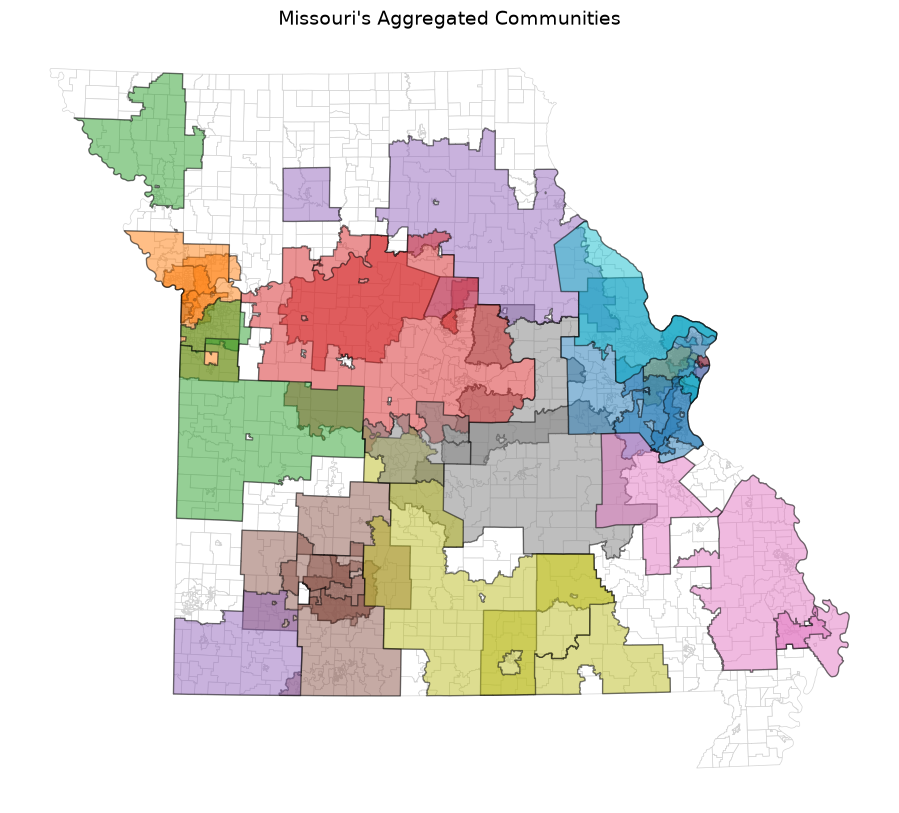

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))

vtds.plot(ax=ax, color="white", edgecolor="lightgray", linewidth=0.5)
cois.plot(ax=ax, column="cluster", alpha=0.5, edgecolor="black")

ax.set_title("Missouri's Aggregated Communities", fontsize=14)
ax.axis("off")
plt.show()

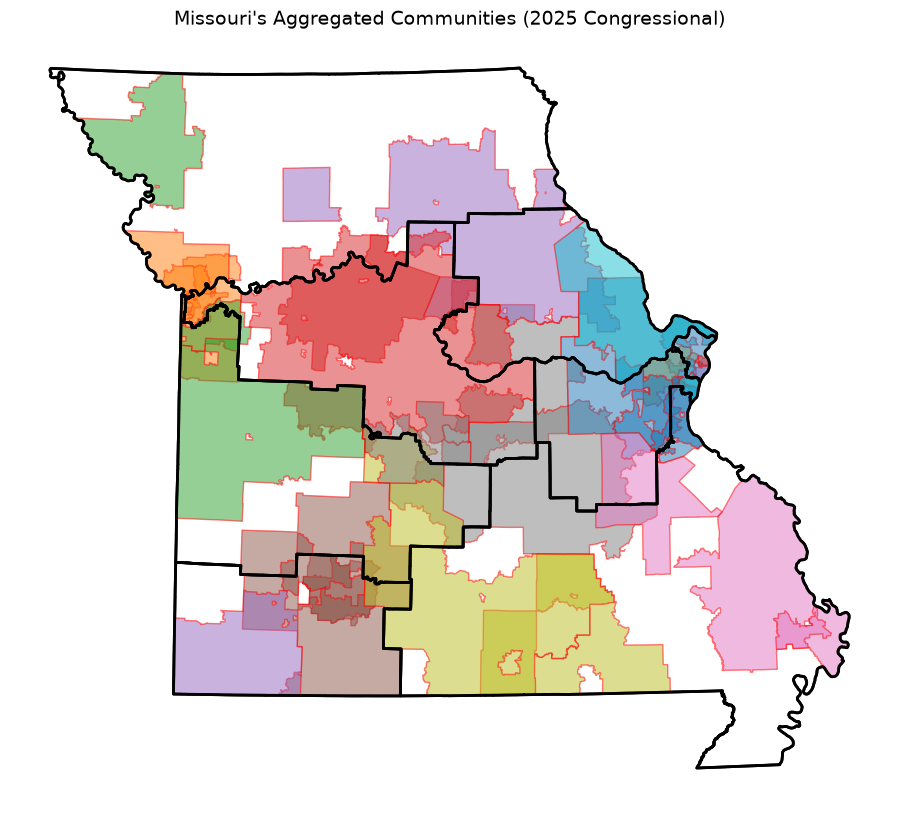

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))

congressional_2025.plot(ax=ax, edgecolor='black', color='white',linewidth=2)
cois.plot(ax=ax, column="cluster",edgecolor="red", alpha=0.5)
congressional_2025.plot(ax=ax, facecolor='none', linewidth=2)

ax.set_title("Missouri's Aggregated Communities (2025 Congressional)", fontsize=14)
ax.axis("off")
plt.show()

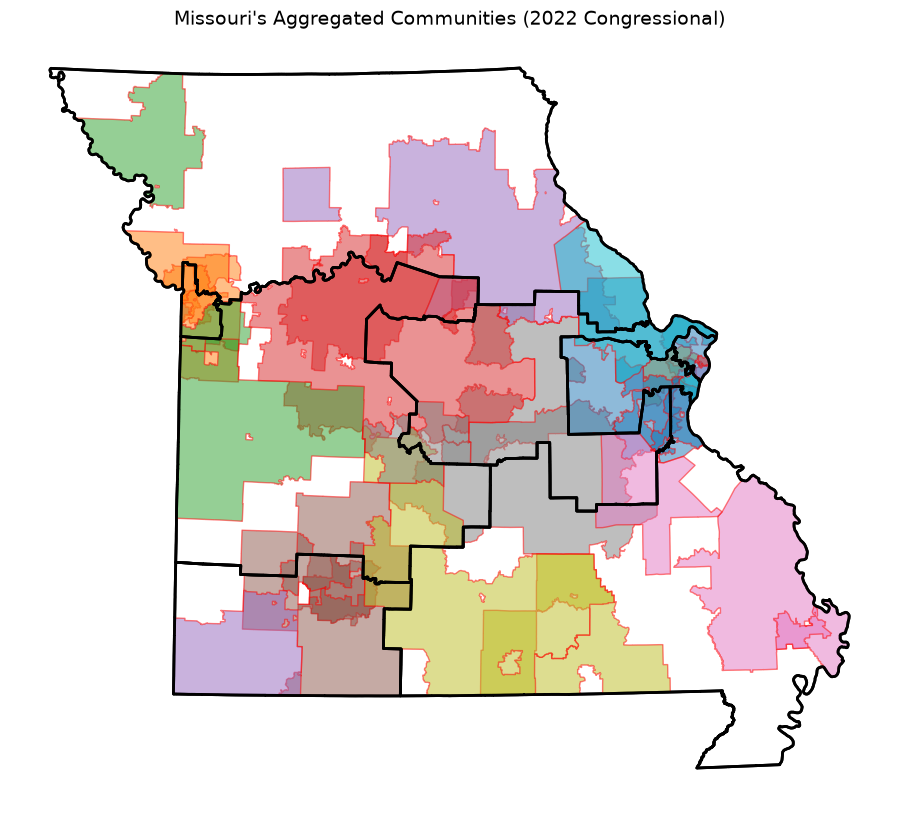

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))

congressional_2022.plot(ax=ax, edgecolor='black', color='white',linewidth=2)
cois.plot(ax=ax, column="cluster",edgecolor="red", alpha=0.5)
congressional_2022.plot(ax=ax, facecolor='none', linewidth=2)

ax.set_title("Missouri's Aggregated Communities (2022 Congressional)", fontsize=14)
ax.axis("off")
plt.show()

### Partition Maps

plotting most preserved map:
tcp score: 0.608
cut edges: 565
dem seats won: 2/8


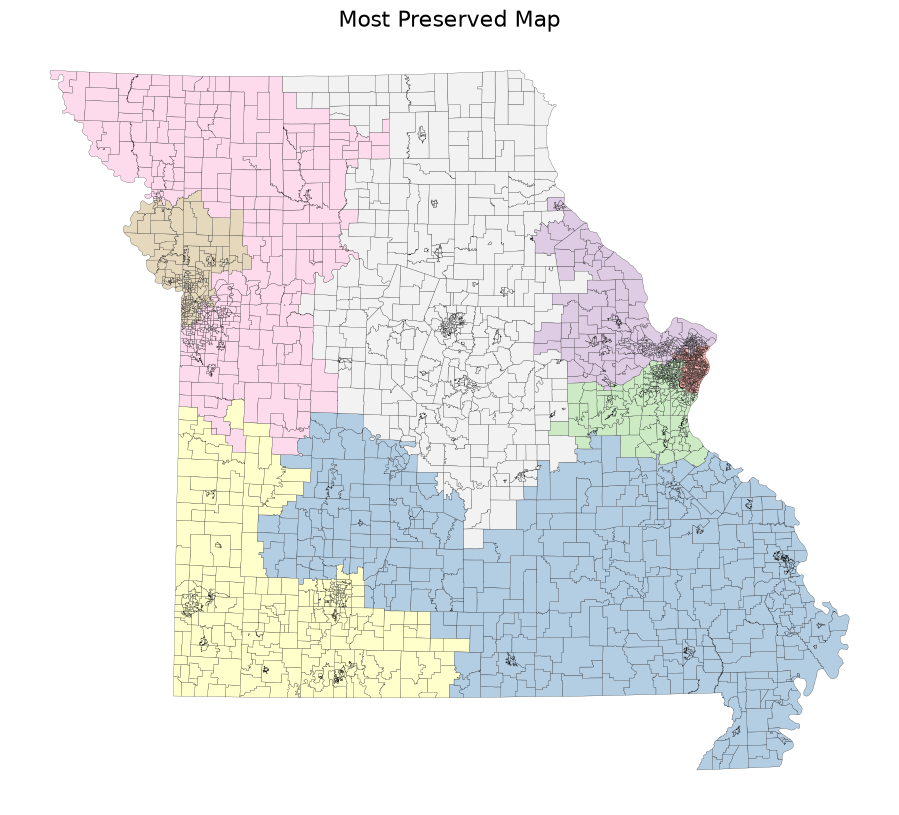

plotting least preserved map:
tcp score: 0.545
cut edges: 647
dem seats won: 2/8


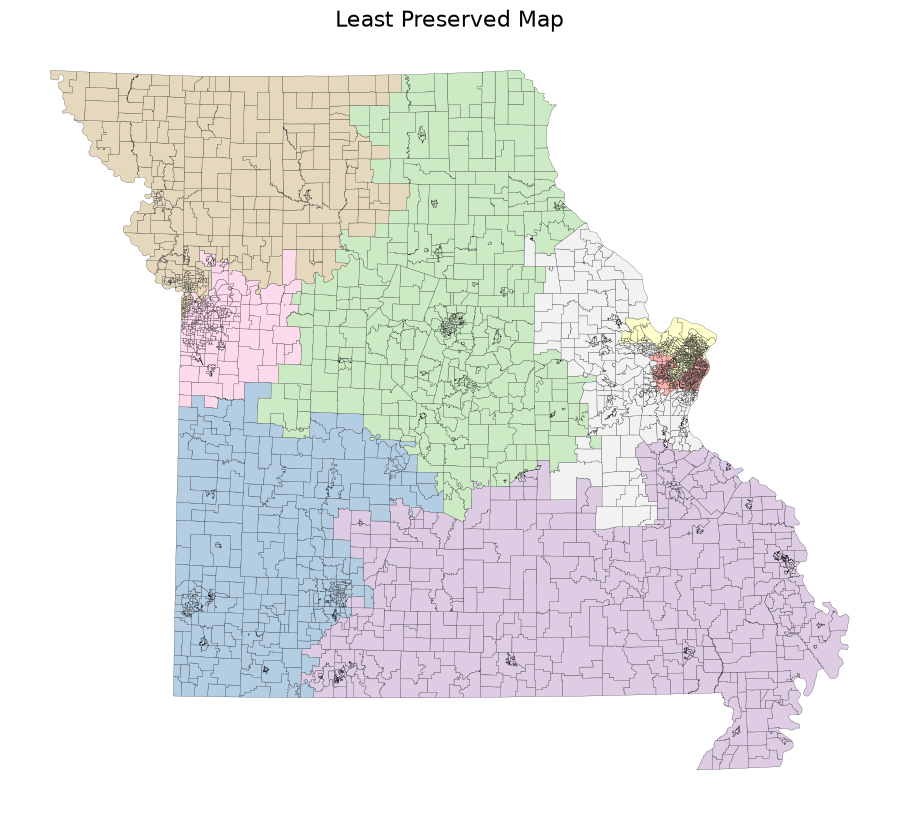

plotting best max representation map:
tcp score: 0.595
cut edges: 474
dem seats won: 3/8


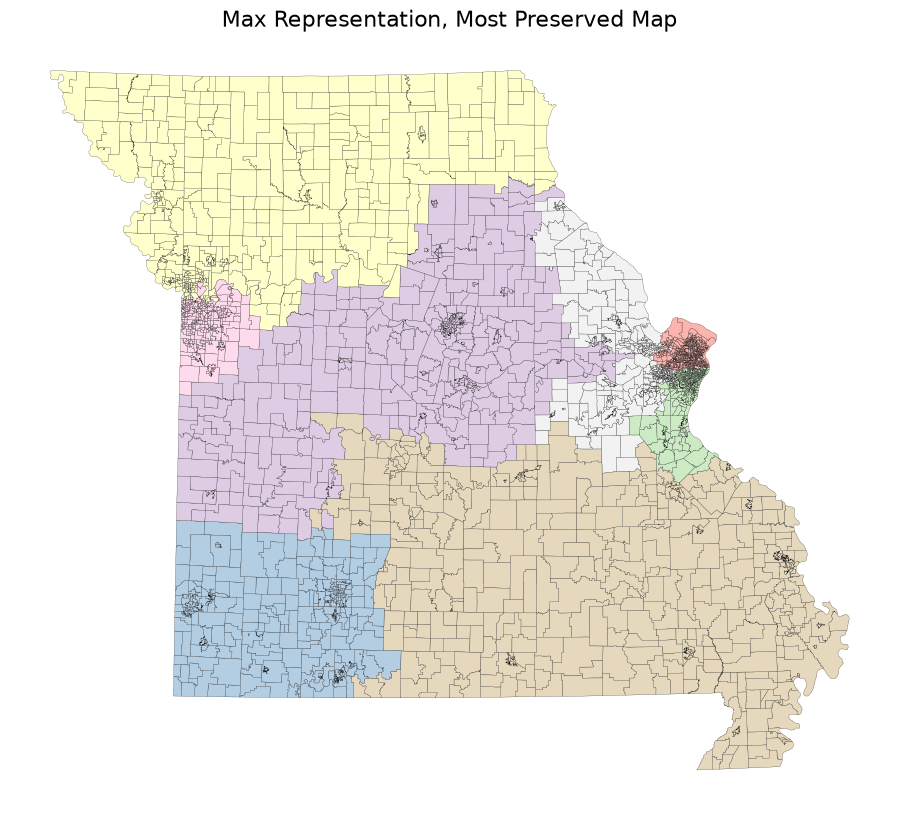

plotting enacted map (2025):
tcp score: 0.531
cut edges: 565
dem seats won: 1/8


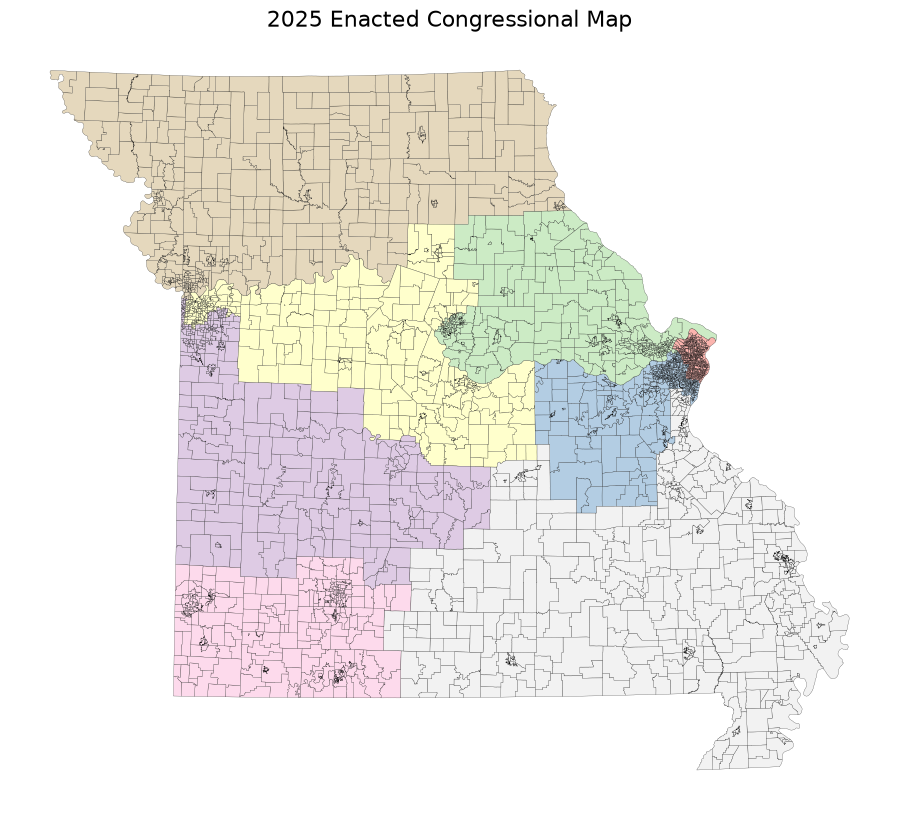

plotting enacted map (2022):
tcp score: 0.520
cut edges: 653
dem seats won: 2/8


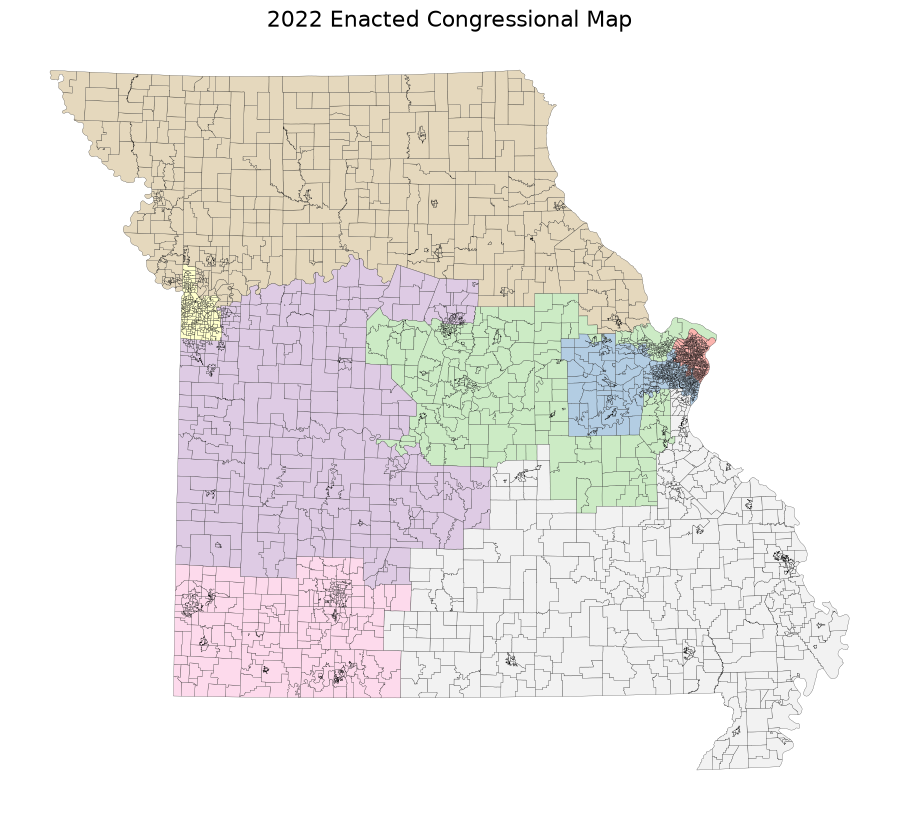

In [ ]:
# plotted partition maps
print("plotting most preserved map:")
print(f"tcp score: {best_map['tcp_score']:.3f}")
print(f"cut edges: {len(best_map['cut_edges'])}")
print(f"dem seats won: {best_map['dem_wins']}/8")
plot_partition(best_map, vtds, cois, 'Most Preserved Map')

print("plotting least preserved map:")
print(f"tcp score: {worst_map['tcp_score']:.3f}")
print(f"cut edges: {len(worst_map['cut_edges'])}")
print(f"dem seats won: {worst_map['dem_wins']}/8")
plot_partition(worst_map, vtds, cois, 'Least Preserved Map')

print("plotting best max representation map:")
print(f"tcp score: {overall_best_map['tcp_score']:.3f}")
print(f"cut edges: {len(overall_best_map['cut_edges'])}")
print(f"dem seats won: {overall_best_map['dem_wins']}/8")
plot_partition(overall_best_map, vtds, cois, 'Max Representation, Most Preserved Map')

print("plotting enacted map (2025):")
print(f"tcp score: {enacted_2025['tcp_score']:.3f}")
print(f"cut edges: {len(enacted_2025['cut_edges'])}")
print(f"dem seats won: {enacted_2025['dem_wins']}/8")
plot_partition(enacted_2025, vtds, cois, '2025 Enacted Congressional Map')

print("plotting enacted map (2022):")
print(f"tcp score: {enacted_2022['tcp_score']:.3f}")
print(f"cut edges: {len(enacted_2022['cut_edges'])}")
print(f"dem seats won: {enacted_2022['dem_wins']}/8")
plot_partition(enacted_2022, vtds, cois, '2022 Enacted Congressional Map')

In [ ]:
df_2022 = extract_data(enacted_2022)
df_2025 = extract_data(enacted_2025)

community_scores_2022 = score_communities(df_2022)
worst_preserved_2022 = community_scores_2022.sort_values(by='sss_score')

community_scores_2025 = score_communities(df_2025)
worst_preserved_2025 = community_scores_2025.sort_values(by='sss_score')


formatter = {
    'total_pop': '{:,.0f}',  
    'sss_score': '{:.4f}'
}

print("The 10 Most Fractured Communities in 2022:")
display(worst_preserved_2022[['community_id', 'total_pop', 'sss_score']].head(10).style.format(formatter))

print("The 10 Most Preserved Communities in 2022:")
display(worst_preserved_2022[['community_id', 'total_pop', 'sss_score']].tail(10).style.format(formatter))

print("The 10 Most Fractured Communities in 2025:")
display(worst_preserved_2025[['community_id', 'total_pop', 'sss_score']].head(10).style.format(formatter))

print("The 10 Most Preserved Communities in 2025:")
display(worst_preserved_2025[['community_id', 'total_pop', 'sss_score']].tail(10).style.format(formatter))



The 10 Most Fractured Communities in 2022:


,community_id,total_pop,sss_score
0,C1,"1,169,254",0.2718
33,C6,"109,035",0.2820
28,C33,"84,605",0.2872
34,C7,"322,712",0.3525
30,C35,"125,421",0.3578
2,C11,"91,804",0.3861
12,C20,"274,393",0.4419
1,C10,"141,467",0.4490
4,C13,"573,119",0.4502
14,C21-2,"50,184",0.4917


The 10 Most Preserved Communities in 2022:


,community_id,total_pop,sss_score
31,C4,"51,531",0.9070
27,C32,"40,008",0.9381
29,C34,"31,561",0.9663
35,C8,"106,875",0.9707
22,C28,"11,060",1.0000
16,C23,"6,757",1.0000
6,C15,"99,375",1.0000
3,C12,"49,737",1.0000
24,C3,"88,408",1.0000
11,C2,"33,404",1.0000


The 10 Most Fractured Communities in 2025:


,community_id,total_pop,sss_score
0,C1,"1,169,254",0.2708
33,C6,"109,035",0.2820
28,C33,"84,605",0.2861
4,C13,"573,119",0.3401
27,C32,"40,008",0.3568
15,C22,"84,584",0.3588
30,C35,"125,421",0.4008
7,C16,"183,465",0.4272
12,C20,"274,393",0.4524
6,C15,"99,375",0.4777


The 10 Most Preserved Communities in 2025:


,community_id,total_pop,sss_score
9,C18,"82,800",0.8342
5,C14,"148,765",0.8453
31,C4,"51,531",0.8821
23,C29,"97,748",0.8939
17,C24,"60,975",0.8965
29,C34,"31,561",0.9663
11,C2,"33,404",1.0000
22,C28,"11,060",1.0000
16,C23,"6,757",1.0000
24,C3,"88,408",1.0000
